首先，我们需要导入必要的库并获取 MNIST 数据集。
在纯 NumPy 实现中，我们使用 sklearn 来便捷地下载标准数据集。
我们将对图像数据进行归一化处理（缩放到 0-1 之间），以加快梯度下降的收敛速度。

In [3]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Downloading MNIST dataset...")
mnist = fetch_openml("mnist_784", version=1, cache=True, parser="auto")
X, y = mnist["data"], mnist["target"]

# 2. 数据预处理
# 将像素值归一化到 0 到 1 之间
X = X.to_numpy() / 255.0
# 标签转换为整数类型
y = y.to_numpy().astype(int)

# 3. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (56000, 784)
Test data shape: (14000, 784)


我们将构建一个两层网络（输入层不计入层数）：
输入层：784 个节点（对应 28x28 的展平图像）
隐藏层：128 个节点，使用 ReLU 激活函数
输出层：10 个节点，使用 Softmax 激活函数（对应 0-9 个数字类别）

前向传播 (Forward Propagation):
$$Z^{[1]}=XW^{[1]}+b^{[1]}$$
$$A^{[1]}=\text{ReLU}(Z^{[1]})$$
$$Z^{[2]}=A^{[1]}W^{[2]}+b^{[2]}$$
$$A^{[2]}=\text{Softmax}(Z^{[2]})$$
反向传播 (Backward Propagation):
使用交叉熵损失函数，输出层误差 $dZ^{[2]}$ 可以直接简化为预测概率分布与真实One-hot标签的差值。
$$dZ^{[2]}=A^{[2]}-Y$$
$$dW^{[2]}=\frac{1}{m}(A^{[1]})^T dZ^{[2]}$$
$$db^{[2]}=\frac{1}{m}\sum dZ^{[2]}$$
$$dZ^{[1]}=(dZ^{[2]}(W^{[2]})^T)\odot\text{ReLU}'(Z^{[1]})$$
$$dW^{[1]}=\frac{1}{m}X^T dZ^{[1]}$$
$$db^{[1]}=\frac{1}{m}\sum dZ^{[1]}$$

In [4]:
def init_params(input_size=784, hidden_size=128, output_size=10):
    # 使用 He 初始化 (适用于 ReLU)
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
    b1 = np.zeros((1, hidden_size))
    # 输出层使用标准的缩放初始化
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2


def relu(Z):
    return np.maximum(0, Z)


def relu_deriv(Z):
    return Z > 0


def softmax(Z):
    # 减去最大值防止指数爆炸 (数值稳定性优化)
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


def one_hot(Y, num_classes=10):
    one_hot_Y = np.zeros((Y.size, num_classes))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y


def forward_prop(W1, b1, W2, b2, X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[0]
    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * np.dot(A1.T, dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = (1 / m) * np.dot(X.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

我们将实现一个基础的全批量梯度下降。
在计算准确率时，我们直接取 Softmax 输出中概率最大的索引作为预测结果。

In [5]:
def get_predictions(A2):
    return np.argmax(A2, axis=1)


def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size


def train_network(X, Y, epochs=500, learning_rate=0.1):
    W1, b1, W2, b2 = init_params()

    for i in range(epochs):
        # 前向传播
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)

        # 反向传播
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)

        # 参数更新
        W1, b1, W2, b2 = update_params(
            W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate
        )

        # 打印日志
        if i % 50 == 0:
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y)
            print(f"Epoch: {i} | Training Accuracy: {accuracy:.4f}")

    return W1, b1, W2, b2


# 开始训练
print("Starting training...")
W1, b1, W2, b2 = train_network(X_train, y_train, epochs=300, learning_rate=0.5)

Starting training...
Epoch: 0 | Training Accuracy: 0.1148
Epoch: 50 | Training Accuracy: 0.8781
Epoch: 100 | Training Accuracy: 0.9114
Epoch: 150 | Training Accuracy: 0.9236
Epoch: 200 | Training Accuracy: 0.9321
Epoch: 250 | Training Accuracy: 0.9393


Test Set Accuracy: 0.9411


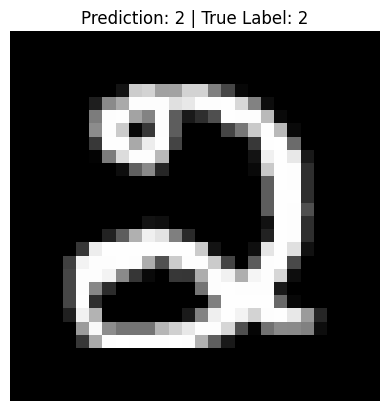

In [7]:
# 在测试集上评估模型
_, _, _, A2_test = forward_prop(W1, b1, W2, b2, X_test)
test_predictions = get_predictions(A2_test)
test_accuracy = get_accuracy(test_predictions, y_test)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# 可视化一个预测结果
index = np.random.randint(0, X_test.shape[0])
img = X_test[index].reshape(28, 28)
plt.imshow(img, cmap="gray")
plt.title(f"Prediction: {test_predictions[index]} | True Label: {y_test[index]}")
plt.axis("off")
plt.show()